In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv("smart_mobility_dataset.csv")
df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


In [2]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"])

In [3]:
# Extract useful features
df['hour'] = df['Timestamp'].dt.hour
df['day'] = df['Timestamp'].dt.day

In [4]:
num_col=df.select_dtypes(include=["int64","float64"]).columns.tolist()
cal_col=df.select_dtypes(include=["object","category"]).columns.tolist()

In [5]:
num_col

['Latitude',
 'Longitude',
 'Vehicle_Count',
 'Traffic_Speed_kmh',
 'Road_Occupancy_%',
 'Accident_Report',
 'Sentiment_Score',
 'Ride_Sharing_Demand',
 'Parking_Availability',
 'Emission_Levels_g_km',
 'Energy_Consumption_L_h']

In [6]:
cal_col

['Traffic_Light_State', 'Weather_Condition', 'Traffic_Condition']

In [7]:
for col in cal_col:
    print(df[col].value_counts())

Traffic_Light_State
Yellow    1726
Green     1651
Red       1623
Name: count, dtype: int64
Weather_Condition
Rain     1279
Snow     1257
Fog      1245
Clear    1219
Name: count, dtype: int64
Traffic_Condition
High      3166
Medium    1475
Low        359
Name: count, dtype: int64


In [8]:
weather_map = {
    'Clear': 0,
    'Snow': 1,
    'Fog': 3,
    'Rain': 4
}
signal_map = {
    'Red': 1,
    'Yellow': 2,
    'Green': 0
}
traffic_map={
    'High':2,
    'Medium':1,
    'Low':0

}    
df["Weather_Condition"] = df["Weather_Condition"].map(weather_map)
df["Traffic_Light_State"] = df["Traffic_Light_State"].map(signal_map)
df["Traffic_Condition"] = df["Traffic_Condition"].map(traffic_map)

In [9]:
df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,hour,day
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,2,45,450.760055,19.574337,2,0,1
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,16,1,321.800341,5.385554,2,0,1
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,4,0,0.289660,16,49,231.152655,10.277477,2,0,1
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,3,0,-0.271965,66,10,410.384292,29.243279,2,0,1
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,1,0,-0.797606,3,5,364.466342,16.801459,0,0,1


In [10]:
df.describe()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,hour,day
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-03-09 16:17:30,40.749645,-73.847433,153.921200,42.111096,54.748397,1.015000,2.02160,0.096000,-0.005652,50.487800,24.613000,272.174927,17.343243,1.561400,11.340800,9.187200
min,2024-03-01 00:00:00,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,0.00000,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787,0.000000,0.000000,1.000000
25%,2024-03-05 08:08:45,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,1.00000,0.000000,-0.500154,26.000000,12.000000,160.564433,11.098761,1.000000,5.000000,5.000000
50%,2024-03-09 16:17:30,40.748875,-73.846058,156.000000,42.191599,54.657297,1.000000,3.00000,0.000000,-0.010564,50.000000,24.000000,272.045513,17.153791,2.000000,11.000000,9.000000
75%,2024-03-14 00:26:15,40.824735,-73.771685,226.000000,60.751760,77.581720,2.000000,4.00000,0.000000,0.500518,75.000000,37.000000,382.242055,23.516595,2.000000,17.000000,14.000000
max,2024-03-18 08:35:00,40.899972,-73.700159,299.000000,79.997556,99.999729,2.000000,4.00000,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416,2.000000,23.000000,18.000000
std,NaN,0.086123,0.086204,83.523342,21.707720,26.145238,0.821773,1.58077,0.294621,0.583790,28.484426,14.532511,130.086372,7.208277,0.624426,6.946474,5.015535


In [11]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Define features and Target

In [12]:
X = df.drop(['Timestamp','Traffic_Condition'], axis=1)
y = df['Traffic_Condition']

In [13]:
X.iloc[:5,:13]

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
0,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,2,45,450.760055,19.574337
1,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,16,1,321.800341,5.385554
2,40.819549,-73.732462,252,46.889699,82.772465,0,4,0,0.289660,16,49,231.152655,10.277477
3,40.725849,-73.980134,37,5.730536,37.695567,1,3,0,-0.271965,66,10,410.384292,29.243279
4,40.813265,-73.961631,64,61.348034,22.313358,1,1,0,-0.797606,3,5,364.466342,16.801459


# Train Test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Load model

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Train our model

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=10,          # limit tree depth
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


* n_estimators = 100 → The model builds 100 decision trees and votes across them.
* criterion = 'gini' → Uses Gini impurity to decide splits (how “pure” each node is).
* max_depth = 10 → Each tree can grow up to 10 levels deep, helping prevent overfitting.
* min_samples_split = 2 → A node needs at least 2 samples to split.
* min_samples_leaf = 1 → A leaf can have as little as 1 sample.
* max_features = 'sqrt' → Each split considers only √(features) randomly → adds diversity to trees.
* bootstrap = True → Each tree is trained on a random sample (with replacement) of the data.
* random_state = 42 → Ensures reproducible results.

## Test

In [17]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)  # probabilities

## 8. Evaluation Metrics
* Accuracy

In [18]:
print(y_prob[:10])

[[0.53247757 0.3835256  0.08399683]
 [0.00405529 0.00965225 0.98629246]
 [0.21591826 0.63027111 0.15381063]
 [0.08817053 0.81187612 0.09995336]
 [0.         0.         1.        ]
 [0.         0.04136886 0.95863114]
 [0.02772347 0.10879779 0.86347874]
 [0.00520101 0.0800085  0.91479049]
 [0.00629332 0.05017167 0.94353501]
 [0.01908347 0.04255683 0.9383597 ]]


In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.994


### Precision, Recall, F1-score

In [20]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Precision:", round(precision,4))
print("Recall:", recall)
print("F1 Score:", round(f1,4))

Precision: 0.9941
Recall: 0.994
F1 Score: 0.9939


## Confusion Matrics

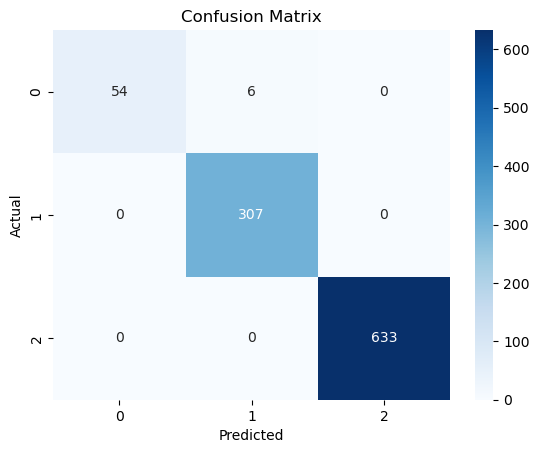

In [21]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Feature Importance

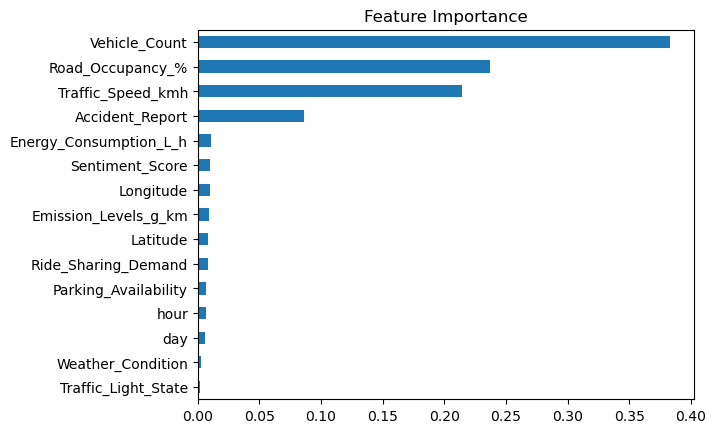

In [22]:
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [23]:
feat_imp

Latitude                  0.008287
Longitude                 0.009840
Vehicle_Count             0.383207
Traffic_Speed_kmh         0.214052
Road_Occupancy_%          0.236797
Traffic_Light_State       0.001862
Weather_Condition         0.002905
Accident_Report           0.086054
Sentiment_Score           0.010203
Ride_Sharing_Demand       0.007995
Parking_Availability      0.006691
Emission_Levels_g_km      0.009111
Energy_Consumption_L_h    0.010773
hour                      0.006322
day                       0.005900
dtype: float64

## Save model

In [24]:
import joblib
joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']

In [25]:
model = joblib.load("rf_model.pkl") 

In [26]:
pred_num = model.predict(X_test)[:50]
print("Numeric prediction:", pred_num)

Numeric prediction: [0 2 1 1 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 1 2 1 2 2 1 2 2 2 2 2 2
 1 2 0 1 1 1 2 2 2 2 2 1 2]


## Get probability

In [27]:
probs = model.predict_proba(X_test)[:10]

print("Probabilities:", probs)

Probabilities: [[0.53247757 0.3835256  0.08399683]
 [0.00405529 0.00965225 0.98629246]
 [0.21591826 0.63027111 0.15381063]
 [0.08817053 0.81187612 0.09995336]
 [0.         0.         1.        ]
 [0.         0.04136886 0.95863114]
 [0.02772347 0.10879779 0.86347874]
 [0.00520101 0.0800085  0.91479049]
 [0.00629332 0.05017167 0.94353501]
 [0.01908347 0.04255683 0.9383597 ]]


## Create reverse mapping

In [28]:
reverse_traffic_map = {v: k for k, v in traffic_map.items()}

In [29]:
pred_num = model.predict(X_test)[1]
pred_label = reverse_traffic_map[pred_num]

print("Numeric:", pred_num)
print("Traffic Condition:", pred_label)

Numeric: 2
Traffic Condition: High


In [30]:
df.describe()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,hour,day
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-03-09 16:17:30,40.749645,-73.847433,153.921200,42.111096,54.748397,1.015000,2.02160,0.096000,-0.005652,50.487800,24.613000,272.174927,17.343243,1.561400,11.340800,9.187200
min,2024-03-01 00:00:00,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,0.00000,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787,0.000000,0.000000,1.000000
25%,2024-03-05 08:08:45,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,1.00000,0.000000,-0.500154,26.000000,12.000000,160.564433,11.098761,1.000000,5.000000,5.000000
50%,2024-03-09 16:17:30,40.748875,-73.846058,156.000000,42.191599,54.657297,1.000000,3.00000,0.000000,-0.010564,50.000000,24.000000,272.045513,17.153791,2.000000,11.000000,9.000000
75%,2024-03-14 00:26:15,40.824735,-73.771685,226.000000,60.751760,77.581720,2.000000,4.00000,0.000000,0.500518,75.000000,37.000000,382.242055,23.516595,2.000000,17.000000,14.000000
max,2024-03-18 08:35:00,40.899972,-73.700159,299.000000,79.997556,99.999729,2.000000,4.00000,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416,2.000000,23.000000,18.000000
std,NaN,0.086123,0.086204,83.523342,21.707720,26.145238,0.821773,1.58077,0.294621,0.583790,28.484426,14.532511,130.086372,7.208277,0.624426,6.946474,5.015535


# Dataset Overview

* From the data you've provided, here are the key columns:

* Timestamp: Time of data capture (helps with time series analysis)

* Latitude, Longitude: Location data (useful for geographical analysis)

* Vehicle_Count: Number of vehicles in the area (can be used for traffic flow analysis)

* Traffic_Speed_kmh: Speed of traffic (key for forecasting congestion and modeling traffic behavior)

* Road_Occupancy_%: Percentage of the road occupied by vehicles (helps in determining traffic density)

* Traffic_Light_State: The state of traffic lights (can be modeled to predict the impact on traffic flow)

* Weather_Condition: Weather condition at the time (important for predicting traffic behavior, as weather affects driving)

* Accident_Report: Indicates if an accident has been reported (used to analyze traffic disruptions and delays)

* Sentiment_Score: Public sentiment score (could help in analyzing public opinion on traffic conditions)

* Ride_Sharing_Demand: The demand for ride-sharing (relevant for modeling demand and predicting service needs)

* Parking_Availability: Parking availability (helps to model the relationship between parking and traffic congestion)

* Emission_Levels_g_km: Emissions based on traffic (can be used to evaluate environmental impacts)

* Energy_Consumption_L_h: Fuel consumption (used to analyze vehicle efficiency)

*Traffic_Condition: The overall traffic condition (label, used for classification and predictive modeling)

### Key Data Science Applications in ITS:

#### 1. Traffic Flow Prediction

* To predict future traffic flow or traffic congestion, you can use historical data to build a predictive model. Here's how we could approach this:

* Time Series Analysis: Use Timestamp to study traffic flow over time (e.g., daily, weekly, or seasonal patterns).

* Predictive Models: Use regression models (e.g., Linear Regression, Random Forest Regressor) to predict Traffic_Speed_kmh or Vehicle_Count based on other factors like Weather_Condition, Traffic_Light_State, and Road_Occupancy_%.

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Assuming df is your dataset
df['Timestamp'] = pd.to_datetime(df['Timestamp'])  # Convert to datetime
df.set_index('Timestamp', inplace=True)

# Use relevant columns for prediction (e.g., Traffic Speed)
X = df[['Road_Occupancy_%', 'Weather_Condition', 'Traffic_Light_State', 'Accident_Report', 'Ride_Sharing_Demand', 'Parking_Availability']]
y = df['Traffic_Speed_kmh']

# Convert categorical variables into numerical (e.g., one-hot encoding)
X = pd.get_dummies(X)

# Split the data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 502.7258991402398


In [5]:
X

,Road_Occupancy_%,Accident_Report,Ride_Sharing_Demand,Parking_Availability,Weather_Condition_Clear,Weather_Condition_Fog,Weather_Condition_Rain,Weather_Condition_Snow,Traffic_Light_State_Green,Traffic_Light_State_Red,Traffic_Light_State_Yellow
Timestamp,,,,,,,,,,,
2024-03-01 00:00:00,82.652780,0,2,45,True,False,False,False,False,False,True
2024-03-01 00:05:00,45.829298,0,16,1,True,False,False,False,True,False,False
2024-03-01 00:10:00,82.772465,0,16,49,False,False,True,False,True,False,False
2024-03-01 00:15:00,37.695567,0,66,10,False,True,False,False,False,True,False
2024-03-01 00:20:00,22.313358,0,3,5,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
2024-03-18 08:15:00,12.670629,0,87,28,False,False,True,False,True,False,False
2024-03-18 08:20:00,49.108556,0,5,0,False,False,False,True,True,False,False
2024-03-18 08:25:00,78.719110,0,94,16,True,False,False,False,False,False,True


### 2. Traffic Congestion Forecasting

* Using historical traffic speed data (e.g., Traffic_Speed_kmh) and vehicle count, you can forecast traffic congestion levels over time and provide insights about when traffic will be high or low.

* Clustering: Use clustering techniques (e.g., K-means) to group similar traffic conditions and predict peak congestion periods based on time and location.

* Classification: Classify the Traffic_Condition column into High, Medium, or Low congestion based on traffic parameters using classifiers like Logistic Regression, Decision Trees, or SVMs.

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Use columns that are relevant for clustering (e.g., Vehicle Count and Traffic Speed)
X = df[['Vehicle_Count', 'Traffic_Speed_kmh']]

# Apply KMeans clustering to identify traffic congestion levels
kmeans = KMeans(n_clusters=3)  # 3 clusters for Low, Medium, High
df['Congestion_Cluster'] = kmeans.fit_predict(X)

# Plot the clusters
plt.scatter(df['Vehicle_Count'], df['Traffic_Speed_kmh'], c=df['Congestion_Cluster'], cmap='viridis')
plt.xlabel('Vehicle Count')
plt.ylabel('Traffic Speed (km/h)')
plt.title('Traffic Congestion Clusters')
plt.show()

### 3. Accident Prediction and Impact Analysis

* You can analyze how weather conditions, traffic light states, and road occupancy affect accidents (e.g., predicting accident probability).

* Classification Models: Use Logistic Regression, Random Forest Classifier, or XGBoost to classify whether an accident will occur based on weather, traffic speed, and road occupancy.

* Impact Analysis: You can assess the impact of accidents on traffic flow by analyzing the changes in Vehicle_Count, Traffic_Speed_kmh, and Road_Occupancy_% following accidents.

### 4. Traffic Optimization

* By analyzing Traffic_Light_State, Vehicle_Count, and Traffic_Speed_kmh, we can optimize traffic light timings to improve overall traffic flow:

* Reinforcement Learning: Use reinforcement learning algorithms (e.g., Q-learning) to optimize traffic light timings to minimize congestion and improve Traffic_Speed_kmh.

### Recommended Training Paths for Data Science in ITS:

* Data Science Bootcamps:

* DataCamp: Offers courses in Time Series Forecasting and Machine Learning applied to transportation.

* Springboard: Provides an advanced Data Science program, including case studies related to traffic analysis and forecasting.
University Programs:

* Georgia Tech: Offers a Master of Science in Transportation Systems, where you can dive deeper into ITS and data science applications.

* MIT: Offers courses in Urban Mobility and Data Science for Transportation.

### Specialized Conferences:

* ITS World Congress: This conference offers workshops and seminars that cover cutting-edge ITS technologies, including machine learning applications for traffic systems.

* Transportation Research Board (TRB) Annual Meeting: A place where researchers, professionals, and students gather to discuss advances in transport data science.

### Conclusion:

* By focusing on predictive modeling, clustering, and classification, you can use data science techniques to improve traffic management, reduce congestion, and predict accidents. The data provided (e.g., traffic speed, weather conditions, vehicle count) can be used to train various machine learning models to forecast traffic behavior and optimize transport systems.